In [1]:
import pandas as pd
import lightgbm as lgb
import json
import joblib
from pathlib import Path
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

In [2]:
def _find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "datasets").is_dir():
            return parent
    raise FileNotFoundError("Could not locate 'datasets' directory above " + str(start))

DATA_DIR = _find_repo_root(Path.cwd()) / "datasets" / "5.0"

with open(f"{DATA_DIR}/features.json") as f:
    feature_metadata = json.load(f)

small_features = feature_metadata["feature_sets"]["small"]
targets = feature_metadata["targets"]
print(f"{len(small_features)} small features, {len(targets)} targets")

42 small features, 37 targets


In [3]:
TARGET = "target"
read_columns = ["era", "data_type", "id"] + small_features + [TARGET]

train = pd.read_parquet(f"{DATA_DIR}/train.parquet", columns=read_columns)
validation = pd.read_parquet(f"{DATA_DIR}/validation.parquet", columns=read_columns)

print(train.shape, validation.shape)
train.head()

(2746268, 45) (4114072, 45)


,era,data_type,feature_antistrophic_striate_conscriptionist,feature_bicameral_showery_wallaba,feature_bridal_fingered_pensioner,feature_collectivist_flaxen_gueux,feature_concurring_fabled_adapter,feature_crosscut_whilom_ataxy,feature_departmental_inimitable_sentencer,feature_dialectal_homely_cambodia,...,feature_trimeter_soggy_greatest,feature_unanalyzable_excusable_whirlwind,feature_unbreakable_constraining_hegelianism,feature_unformed_bent_smatch,feature_unministerial_unextenuated_teleostean,feature_unmodish_zymogenic_rousing,feature_unsystematized_subcardinal_malaysia,feature_willful_sere_chronobiology,feature_zoological_peristomial_scute,target
id,,,,,,,,,,,,,,,,,,,,,
n0007b5abb0c3a25,0001,train,2,2,2,2,2,0,1,2,...,1,1,3,0,2,2,3,3,2,0.25
n003bba8a98662e4,0001,train,2,2,2,2,2,1,4,2,...,2,0,0,0,2,2,4,4,2,0.25
n003bee128c2fcfc,0001,train,2,2,2,2,2,2,2,2,...,1,1,0,1,2,2,0,3,2,0.75
n0048ac83aff7194,0001,train,2,2,2,2,2,1,4,2,...,3,4,1,2,2,2,2,0,2,0.25
n0055a2401ba6480,0001,train,2,2,2,2,2,0,0,2,...,0,1,0,0,2,2,1,4,2,0.25


In [4]:
train = train.dropna(subset=[TARGET])
validation = validation.dropna(subset=[TARGET])

print(train.shape, validation.shape)

(2746268, 45) (4078596, 45)


In [5]:
MODEL_PATH = Path("model_small.pkl")

if MODEL_PATH.exists():
    model = joblib.load(MODEL_PATH)
    print(f"Loaded cached model from {MODEL_PATH}")
else:
    model = lgb.LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.01,
        max_depth=5,
        num_leaves=2 ** 5,
        colsample_bytree=0.1,
        min_child_samples=20,
        verbose=-1,
    )
    model.fit(train[small_features], train[TARGET])
    joblib.dump(model, MODEL_PATH)
    print(f"Trained and cached model to {MODEL_PATH}")

Loaded cached model from model_small.pkl


In [6]:
VALIDATION_PATH = Path("validation.pkl")

if VALIDATION_PATH.exists():
    validation = joblib.load(VALIDATION_PATH)
    print(f"Loaded cached validation data from {VALIDATION_PATH}")
else:
    validation["prediction"] = model.predict(validation[small_features])
    joblib.dump(validation, VALIDATION_PATH)
    print(f"Computed and cached validation data to {VALIDATION_PATH}")

Loaded cached validation data from validation.pkl


In [7]:
ERA_CORR_PATH = Path("per_era_corr_small.pkl")

if ERA_CORR_PATH.exists():
    per_era_corr = joblib.load(ERA_CORR_PATH)
    print(f"Loaded cached per-era correlations from {ERA_CORR_PATH}")
else:
    per_era_corr = validation.groupby("era").apply(lambda df: spearmanr(df["prediction"], df[TARGET])[0], include_groups=False)
    joblib.dump(per_era_corr, ERA_CORR_PATH)
    print(f"Computed and cached per-era correlations to {ERA_CORR_PATH}")

print(f"Mean corr: {per_era_corr.mean():.4f}")
print(f"Std corr:  {per_era_corr.std():.4f}")
print(f"Sharpe:    {per_era_corr.mean() / per_era_corr.std():.4f}")

Loaded cached per-era correlations from per_era_corr_small.pkl
Mean corr: 0.0167
Std corr:  0.0192
Sharpe:    0.8688


Loaded cached exposures from exposures_small.pkl
Feature exposure (RMS): 0.1339
Max feature exposure:   0.2507


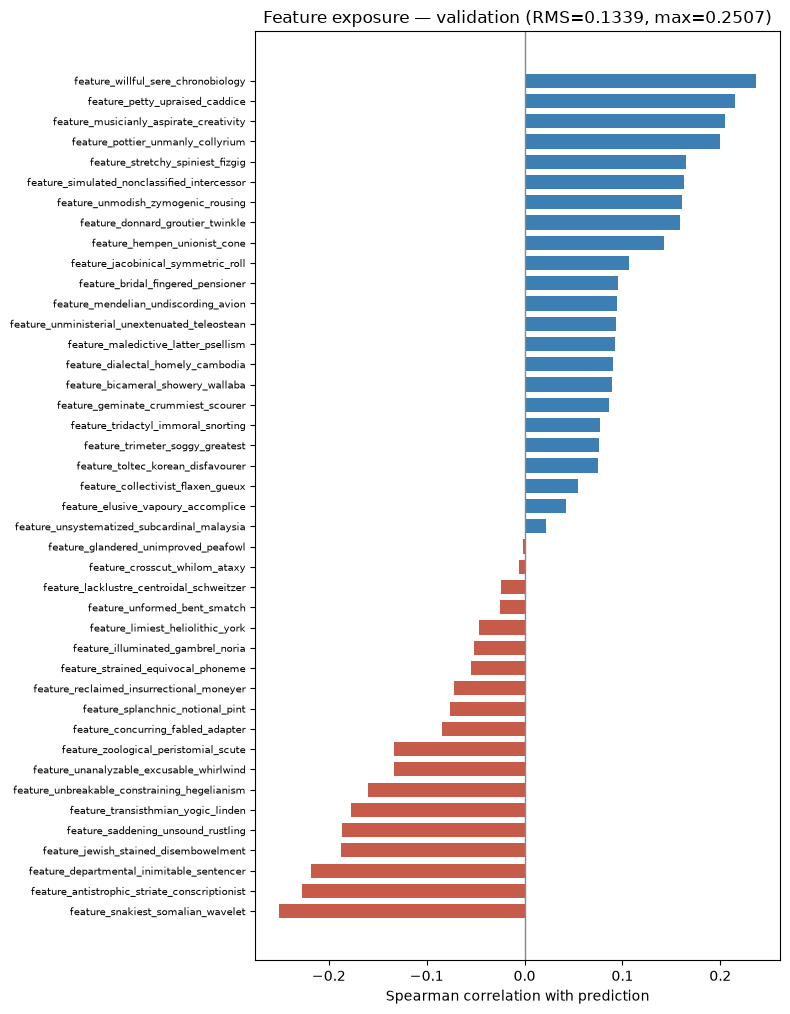

In [8]:
def feature_exposures(df, features, prediction_col="prediction"):
    exposures = [spearmanr(df[prediction_col], df[f])[0] for f in features]
    return np.array(exposures)


def max_feature_exposure(exposures):
    return np.max(np.abs(exposures))


def feature_exposure(exposures):
    return np.sqrt(np.mean(np.square(exposures)))

EXPOSURES_PATH = Path("exposures_small.pkl")

if EXPOSURES_PATH.exists():
    exposures = joblib.load(EXPOSURES_PATH)
    print(f"Loaded cached exposures from {EXPOSURES_PATH}")
else:
    exposures = feature_exposures(validation, small_features)
    joblib.dump(exposures, EXPOSURES_PATH)
    print(f"Computed and cached exposures to {EXPOSURES_PATH}")

max_fe = max_feature_exposure(exposures)
fe = feature_exposure(exposures)
print(f"Feature exposure (RMS): {fe:.4f}")
print(f"Max feature exposure:   {max_fe:.4f}")

order = np.argsort(exposures)
sorted_features = np.array(small_features)[order]
sorted_exposures = exposures[order]
colors = ["#c65b4a" if v < 0 else "#3d7fb3" for v in sorted_exposures]

fig, ax = plt.subplots(figsize=(8, len(small_features) * 0.22 + 1))
ax.barh(sorted_features, sorted_exposures, color=colors, height=0.7)
ax.axvline(0, color="#888888", linewidth=1)
ax.set_xlabel("Spearman correlation with prediction")
ax.set_title(f"Feature exposure — validation (RMS={fe:.4f}, max={max_fe:.4f})")
ax.tick_params(axis="y", labelsize=7)
fig.tight_layout()
plt.show()

# FEATURE NEUTRALIZATION (1 feature)

In [9]:
idx = np.argmax(np.abs(exposures))
max_feature = small_features[idx]
max_exposure = exposures[idx]

In [10]:
MODEL_PATH = Path("model_one_feature_no_neutralization.pkl")

if MODEL_PATH.exists():
    one_feature_model = joblib.load(MODEL_PATH)
    print(f"Loaded cached model from {MODEL_PATH}")
else:
    one_feature_model = lgb.LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.01,
        max_depth=5,
        num_leaves=2 ** 5,
        colsample_bytree=0.1,
        min_child_samples=20,
        verbose=-1,
    )
    one_feature_model.fit(train[[max_feature]], train[TARGET])
    joblib.dump(one_feature_model, MODEL_PATH)
    print(f"Trained and cached model to {MODEL_PATH}")

Loaded cached model from model_one_feature_no_neutralization.pkl


In [11]:
validation["prediction"] = one_feature_model.predict(validation[[max_feature]])

ERA_CORR_PATH_BEFORE = Path("per_era_corr_before_neutralization.pkl")

if ERA_CORR_PATH_BEFORE.exists():
    corr_before = joblib.load(ERA_CORR_PATH_BEFORE)
    print(f"Loaded cached per-era correlations before neutralization from {ERA_CORR_PATH_BEFORE}")
else:
    corr_before = validation.groupby("era").apply(lambda df: spearmanr(df["prediction"], df[TARGET])[0], include_groups=False)
    joblib.dump(corr_before, ERA_CORR_PATH_BEFORE)
    print(f"Computed and cached per-era correlations before neutralization to {ERA_CORR_PATH_BEFORE}")

Loaded cached per-era correlations before neutralization from per_era_corr_before_neutralization.pkl


In [12]:
def neutralize_era(df, feature_col, pred_col, proportion):
    X = df[feature_col].values
    Y = df[pred_col].values
    beta = np.cov(X, Y, ddof=0)[0, 1] / np.var(X)
    return pd.Series(Y - proportion * beta * X, index=df.index)

proportion = 0.5  # 1.0 = fully remove the linear component within each era

ERA_CORR_PATH_AFTER = Path(f"per_era_corr_after_neutralization_{proportion}.pkl")

if ERA_CORR_PATH_AFTER.exists():
    corr_after = joblib.load(ERA_CORR_PATH_AFTER)
    print(f"Loaded cached per-era correlations after neutralization from {ERA_CORR_PATH_AFTER}")
else:
    validation["prediction_neutralized"] = (
        validation.groupby("era", group_keys=False)
        .apply(neutralize_era, feature_col=max_feature, pred_col="prediction", proportion=proportion)
    )
    corr_after = validation.groupby("era").apply(lambda df: spearmanr(df["prediction_neutralized"], df[TARGET])[0])
    joblib.dump(corr_after, ERA_CORR_PATH_AFTER)
    print(f"Computed and cached per-era correlations after neutralization to {ERA_CORR_PATH_AFTER}")

Loaded cached per-era correlations after neutralization from per_era_corr_after_neutralization_0.5.pkl


In [13]:
print(f"Mean corr before: {corr_before.mean():.4f}  Sharpe before: {corr_before.mean()/corr_before.std():.4f}")
print(f"Mean corr after:  {corr_after.mean():.4f}  Sharpe after:  {corr_after.mean()/corr_after.std():.4f}")

Mean corr before: 0.0012  Sharpe before: 0.0807
Mean corr after:  0.0169  Sharpe after:  0.8797


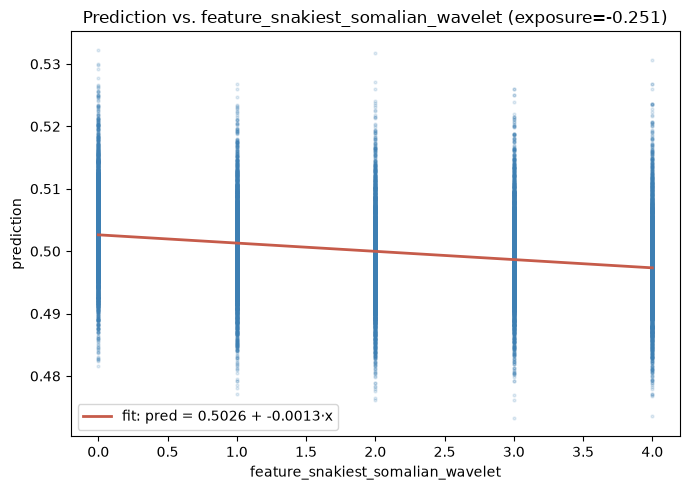

In [18]:
X = validation[max_feature].values
Y = validation["prediction"].values

beta = np.cov(X, Y, ddof=0)[0, 1] / np.var(X)
alpha = Y.mean() - beta * X.mean()

sample = validation.sample(20000, random_state=0)  # subsample for a readable scatter

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sample[max_feature], sample["prediction"], s=4, alpha=0.15, color="#3d7fb3")

x_line = np.linspace(X.min(), X.max(), 100)
ax.plot(x_line, alpha + beta * x_line, color="#c65b4a", linewidth=2,
        label=f"fit: pred = {alpha:.4f} + {beta:.4f}·x")

ax.set_xlabel(max_feature)
ax.set_ylabel("prediction")
ax.set_title(f"Prediction vs. {max_feature} (exposure={max_exposure:.3f})")
ax.legend()
fig.tight_layout()
plt.show()

# FEATURE NEUTRALIZATION (small features)

In [20]:
def neutralize(df, columns, neutralizers, proportion):
    scores = df[columns].values
    exposures = df[neutralizers].values
    exposures = np.hstack((exposures, np.ones((len(exposures), 1))))  # bias term
    correction = proportion * (exposures @ (np.linalg.pinv(exposures) @ scores))
    return scores - correction

VALIDATION_PATH = Path("validation.pkl")

if VALIDATION_PATH.exists():
    validation["prediction"] = joblib.load(VALIDATION_PATH)["prediction"]
    print(f"Loaded cached predictions from {VALIDATION_PATH}")
else:
    validation["prediction"] = model.predict(validation[small_features])
    joblib.dump({"prediction": validation["prediction"]}, VALIDATION_PATH)
    print(f"Computed and cached predictions to {VALIDATION_PATH}")

corr_before_small = validation.groupby("era").apply(
    lambda df: spearmanr(df["prediction"], df[TARGET])[0], include_groups=False
)

proportion = 0.5  # 0.5 = partially remove the linear component within each era

NEUTRALIZED_PATH = Path(f"prediction_neutralized_small_{proportion}.pkl")

if NEUTRALIZED_PATH.exists():
    validation["prediction_neutralized"] = joblib.load(NEUTRALIZED_PATH)
    print(f"Loaded cached neutralized predictions from {NEUTRALIZED_PATH}")
else:
    validation["prediction_neutralized"] = validation.groupby("era", group_keys=False).apply(
        lambda df: pd.Series(
            neutralize(df, ["prediction"], small_features, proportion).ravel(), index=df.index
        )
    )
    joblib.dump(validation["prediction_neutralized"], NEUTRALIZED_PATH)
    print(f"Computed and cached neutralized predictions to {NEUTRALIZED_PATH}")

corr_after_small = validation.groupby("era").apply(
    lambda df: spearmanr(df["prediction_neutralized"], df[TARGET])[0], include_groups=False
)

print(f"Mean corr before: {corr_before_small.mean():.4f}  Sharpe before: {corr_before_small.mean()/corr_before_small.std():.4f}")
print(f"Mean corr after:  {corr_after_small.mean():.4f}  Sharpe after:  {corr_after_small.mean()/corr_after_small.std():.4f}")


Loaded cached predictions from validation.pkl
Computed and cached neutralized predictions to prediction_neutralized_small_0.5.pkl
Mean corr before: 0.0167  Sharpe before: 0.8688
Mean corr after:  0.0154  Sharpe after:  0.8338
